<a href="https://colab.research.google.com/github/fedhilamohamedamine-blip/autoloc-api/blob/main/projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving adult.csv to adult.csv


In [6]:
import pandas as pd

columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education-num',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital-gain',
    'capital-loss',
    'hours-per-week',
    'native-country',
    'income'
]

df = pd.read_csv(
    'adult.csv',
    names=columns,
    skipinitialspace=True
)

In [7]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [9]:
df = df.replace('?', pd.NA)

In [10]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [12]:
colonnes_categorielles = [
    'workclass',
    'occupation',
    'native-country'
]

for col in colonnes_categorielles:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [14]:
print((df == '?').sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [15]:
df = df.drop_duplicates()

In [16]:
df.to_csv('adult_clean.csv', index=False)

In [17]:
from google.colab import files

files.download('adult_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import os

print(os.path.exists('/content/adult_clean.csv'))

True


In [19]:
os.listdir('/content')

['.config', 'adult_dataset', 'adult_clean.csv', 'adult.csv', 'sample_data']

In [21]:
X = df[[
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain"
]]

In [22]:
print(X.isnull().sum())

age               0
education-num     0
hours-per-week    0
capital-gain      0
dtype: int64


In [24]:
print(X.dtypes)
print(X.isnull().sum())
print(X.head())

age               object
education-num     object
hours-per-week    object
capital-gain      object
dtype: object
age               0
education-num     0
hours-per-week    0
capital-gain      0
dtype: int64
   age  education-num  hours-per-week  capital-gain
0  age  education-num  hours-per-week  capital-gain
1   39             13              40          2174
2   50             13              13             0
3   38              9              40             0
4   53              7              40             0


In [25]:
X = df[['age', 'education-num', 'hours-per-week', 'capital-gain']].copy()

X = X.apply(pd.to_numeric, errors='coerce')

print(X.isnull().sum())

age               1
education-num     1
hours-per-week    1
capital-gain      1
dtype: int64


In [26]:
X = X.dropna()

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.03038995  1.13477712 -0.03566374  0.14829174]
 [ 0.8369732   1.13477712 -2.22248299 -0.14597544]
 [-0.0429358  -0.42067868 -0.03566374 -0.14597544]
 [ 1.05695045 -1.19840658 -0.03566374 -0.14597544]
 [-0.7761933   1.13477712 -0.03566374 -0.14597544]]


In [28]:
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

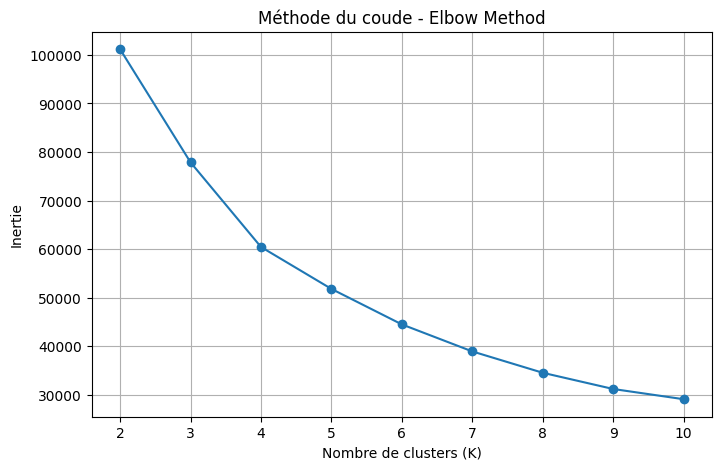

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertias, marker='o')

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.title("Méthode du coude - Elbow Method")
plt.grid(True)

plt.show()

In [31]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print("K =", k, "→ Silhouette =", round(score, 4))

K = 2 → Silhouette = 0.8369
K = 3 → Silhouette = 0.2441
K = 4 → Silhouette = 0.2844
K = 5 → Silhouette = 0.2933
K = 6 → Silhouette = 0.309
K = 7 → Silhouette = 0.3198
K = 8 → Silhouette = 0.3214
K = 9 → Silhouette = 0.3213
K = 10 → Silhouette = 0.2882


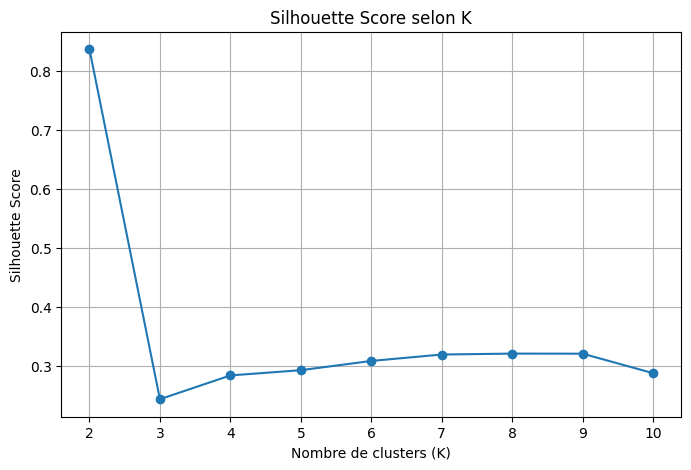

In [32]:
from sklearn.preprocessing import StandardScaler
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score selon K")
plt.grid(True)

plt.show()

In [36]:
from sklearn.cluster import KMeans

k = 8

k_means = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Aligner df avec l'index de X pour exclure la ligne d'en-tête textuelle
df = df.loc[X.index].copy()

df['cluster'] = k_means.fit_predict(X_scaled)

print(df['cluster'].value_counts().sort_index())

cluster
0    2457
1    7147
2    9700
3     159
4    1307
5    2101
6    6441
7    3225
Name: count, dtype: int64


In [38]:
# Définir la liste des caractéristiques utilisées pour le clustering
features = ['age', 'education-num', 'hours-per-week', 'capital-gain']

# S'assurer que ces colonnes sont bien au format numérique dans df pour pouvoir calculer la moyenne
df[features] = df[features].apply(pd.to_numeric, errors='coerce')

profil_clusters = df.groupby('cluster')[features].mean()

profil_clusters

,age,education-num,hours-per-week,capital-gain
cluster,,,,
0,39.655678,10.487586,65.815222,780.310541
1,39.346579,13.377361,43.204561,1238.847349
2,29.283196,9.314948,41.130619,256.548351
3,46.358491,12.918239,49.798742,99999.000000
4,65.192043,9.917368,17.820964,622.637337
5,44.921942,4.431223,39.828177,204.251785
6,51.308492,9.549449,41.232417,672.981835
7,23.358450,9.447132,20.428527,109.179225


In [39]:
profil_clusters = df.groupby('cluster')[features].mean()

profil_clusters

,age,education-num,hours-per-week,capital-gain
cluster,,,,
0,39.655678,10.487586,65.815222,780.310541
1,39.346579,13.377361,43.204561,1238.847349
2,29.283196,9.314948,41.130619,256.548351
3,46.358491,12.918239,49.798742,99999.000000
4,65.192043,9.917368,17.820964,622.637337
5,44.921942,4.431223,39.828177,204.251785
6,51.308492,9.549449,41.232417,672.981835
7,23.358450,9.447132,20.428527,109.179225


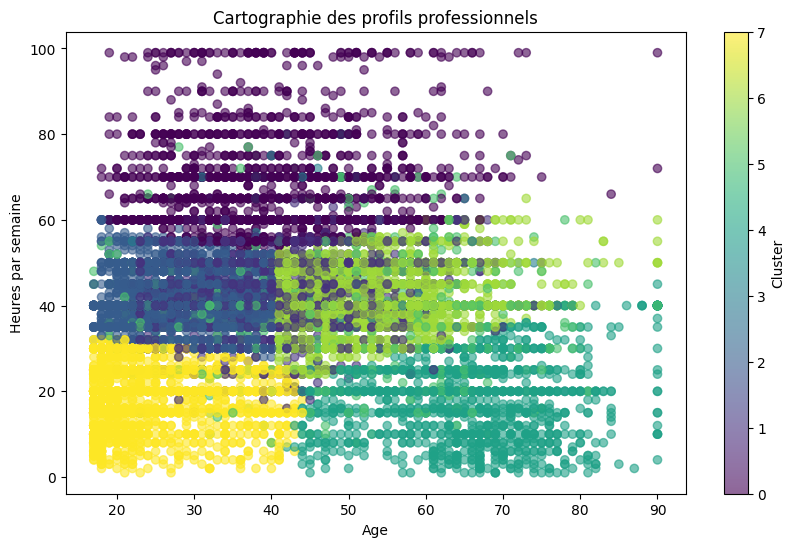

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['age'],
    df['hours-per-week'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Heures par semaine")
plt.title("Cartographie des profils professionnels")
plt.colorbar(label="Cluster")

plt.show()

In [41]:
df.to_csv(
    '/content/adult_clustering_final.csv',
    index=False
)

print("Dataset sauvegardée avec succès.")

Dataset sauvegardée avec succès.


In [42]:
from google.colab import files

files.download('/content/adult_clustering_final.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>